In [11]:
import torch
from torch import nn
import os
from d2l import torch as d2l

In [12]:
import requests
import zipfile
import hashlib

# 1. 配置下载信息
DATA_URL = 'http://d2l-data.s3-accelerate.amazonaws.com/'
DATA_HUB = {
    'fra-eng': (DATA_URL + 'fra-eng.zip',
                '94646ad1522d915e7b0f9296181140edcf86a4f5')
}

def download_extract(name, cache_dir='../data'):
   
    os.makedirs(cache_dir, exist_ok=True)
    url, sha1_hash = DATA_HUB[name]
    fname = os.path.join(cache_dir, url.split('/')[-1])
    
    
    if not os.path.exists(fname):
        print(f"正在下载 {name} ...")
        r = requests.get(url)
        r.raise_for_status()
        with open(fname, 'wb') as f:
            f.write(r.content)
    
    ## 校验 SHA-1 hashcode
    sha1 = hashlib.sha1()
    with open(fname, 'rb') as f:
        while True:
            data = f.read(1048576)  # 每次读 1MB
            if not data:
                break
            sha1.update(data)
    if sha1.hexdigest() != sha1_hash:
        raise ValueError(f"{fname} 哈希校验失败，文件可能已损坏。")
    
    
    data_dir = os.path.join(cache_dir, name)
    if not os.path.exists(data_dir):
        with zipfile.ZipFile(fname, 'r') as z:
            z.extractall(cache_dir)
    return data_dir


def read_data_nmt():
    
    data_dir = download_extract('fra-eng')
    with open(os.path.join(data_dir, 'fra.txt'), 'r', encoding='utf-8') as f:
        return f.read()


raw_text = read_data_nmt()
print(raw_text[:75])

Go.	Va !
Hi.	Salut !
Run!	Cours !
Run!	Courez !
Who?	Qui ?
Wow!	Ça alors !



In [13]:
def preprocess_nmt(text):
  ## 在标点前面加空格，让标点符号成为单独一个 token
    def no_space(char, prev_char):
        return char in set(',.!?') and prev_char != ' '

    ## 用普通空格替换特殊 Unicode 空格（\u202f, \xa0），转小写减少词表大小
    text = text.replace('\u202f', ' ').replace('\xa0', ' ').lower()

    out = [
        ' ' + char if i > 0 and no_space(char, text[i - 1])
        else char
        for i, char in enumerate(text)
    ]
    return ''.join(out)

In [14]:
text = preprocess_nmt(raw_text)
print(text[:80])

go .	va !
hi .	salut !
run !	cours !
run !	courez !
who ?	qui ?
wow !	ça alors !


In [15]:
def tokenize_nmt(text,num_examples=None):
    source, target = [],[]
    for i, line in enumerate(text.split('\n')):
        if num_examples and i > num_examples:
            break
        parts = line.split('\t')
        if len(parts) == 2:
            source.append(parts[0].split(' '))
            target.append(parts[1].split(' '))
    return source,target

In [16]:
source, target = tokenize_nmt(text)
source[:6], target[:6]

([['go', '.'],
  ['hi', '.'],
  ['run', '!'],
  ['run', '!'],
  ['who', '?'],
  ['wow', '!']],
 [['va', '!'],
  ['salut', '!'],
  ['cours', '!'],
  ['courez', '!'],
  ['qui', '?'],
  ['ça', 'alors', '!']])

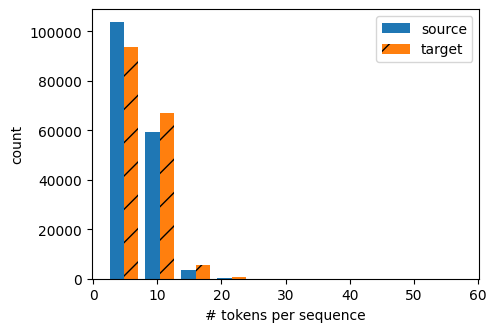

In [17]:
import matplotlib.pyplot as plt

def show_list_len_pair_hist(legend, xlabel, ylabel, xlist, ylist):
    """绘制列表长度对的直方图"""
    plt.figure(figsize=(5, 3.5))  # 替代 d2l.set_figsize()
    _, _, patches = plt.hist(
        [[len(l) for l in xlist], [len(l) for l in ylist]]
    )
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    # 给第二个直方图加上斜线填充，方便区分重叠部分
    for patch in patches[1].patches:
        patch.set_hatch('/')
    plt.legend(legend)
    plt.show()


show_list_len_pair_hist(
    ['source', 'target'],       
    '# tokens per sequence',    
    'count',                   
    source, target           
)

In [21]:
import collections


class Vocab:
    def __init__(self, tokens=None, min_freq=0, reserved_tokens=None):
        if tokens is None:
            tokens = []
        if reserved_tokens is None:
            reserved_tokens = []
        # 统计词频
        counter = collections.Counter(tokens)
        self._token_freqs = sorted(counter.items(), key=lambda x: x[1], reverse=True)
        # idx to token：<unk> 固定为 0，然后是保留词元
        self.idx_to_token = ['<unk>'] + reserved_tokens
        self.token_to_idx = {token: idx for idx, token in enumerate(self.idx_to_token)}
        for token, freq in self._token_freqs:
            if freq < min_freq:
                break
            if token not in self.token_to_idx:
                self.idx_to_token.append(token)
                self.token_to_idx[token] = len(self.idx_to_token) - 1

    def __len__(self):
        return len(self.idx_to_token)

    def __getitem__(self, tokens):
        if not isinstance(tokens, (list, tuple)):
            return self.token_to_idx.get(tokens, self.unk)
        return [self.__getitem__(t) for t in tokens]

    def to_tokens(self, indices):
        if not isinstance(indices, (list, tuple)):
            return self.idx_to_token[indices]
        return [self.idx_to_token[i] for i in indices]

    @property
    def unk(self):
        return 0


# 1. 把 source（列表的列表）摊平成一个词元列表
flat_tokens = [token for line in source for token in line]

# 2. 构建词汇表
src_vocab = Vocab(flat_tokens,
                  min_freq=2,
                  reserved_tokens=['<pad>', '<bos>', '<eos>'])

print("源语言词汇表大小:", len(src_vocab))
print("前 10 个 token:", src_vocab.idx_to_token[:10])

源语言词汇表大小: 10012
前 10 个 token: ['<unk>', '<pad>', '<bos>', '<eos>', '.', 'i', 'you', 'to', 'the', '?']


In [19]:
def truncate_pad(line,num_steps,padding_token):
    if len(line) > num_steps:
        return line[:num_steps]
    return line + [padding_token]* (num_steps - len(line))

In [22]:
truncate_pad(src_vocab[source[0]], 10, src_vocab['<pad>'])

[47, 4, 1, 1, 1, 1, 1, 1, 1, 1]

In [24]:
def build_array_nmt(lines,vocab,num_steps):
    lines = [vocab[l] for l in lines]
    lines = [
        l + [vocab['<eos>']] for l in lines
    ]
    array = torch.tensor(
        [
            truncate_pad(l,num_steps,vocab['<pad>']) for l in lines
        ]
    )
    valid_len = (array != vocab['<pad>']).type(torch.int32).sum(1)
    return array,valid_len

In [26]:
import torch
import torch.utils.data as data
import collections
import os
import re
import requests
import zipfile


def load_array(data_arrays, batch_size, is_train=True):
    dataset = data.TensorDataset(*data_arrays)
    return data.DataLoader(dataset, batch_size, shuffle=is_train)


def load_data_nmt(batch_size, num_steps, num_examples=600):
    text = preprocess_nmt(read_data_nmt())
    source, target = tokenize_nmt(text, num_examples)
    src_vocab = Vocab(source, min_freq=2, reserved_tokens=['<pad>', '<bos>', '<eos>'])
    tgt_vocab = Vocab(target, min_freq=2, reserved_tokens=['<pad>', '<bos>', '<eos>'])
    src_array, src_valid_len = build_array_nmt(source, src_vocab, num_steps)
    tgt_array, tgt_valid_len = build_array_nmt(target, tgt_vocab, num_steps)
    data_arrays = (src_array, src_valid_len, tgt_array, tgt_valid_len)
    data_iter = load_array(data_arrays, batch_size, is_train=True)
    return data_iter, src_vocab, tgt_vocab

In [27]:
train_iter, src_vocab, tgt_vocab = load_data_nmt(batch_size=2, num_steps=8)

print("源语言词表大小:", len(src_vocab))
print("目标语言词表大小:", len(tgt_vocab))

for X, X_valid_len, Y, Y_valid_len in train_iter:
    print('X shape:', X.shape)                # (2, 8)
    print('X_valid_len:', X_valid_len)        # (2,)
    print('Y shape:', Y.shape)                # (2, 8)
    print('Y_valid_len:', Y_valid_len)        # (2,)
    break

源语言词表大小: 184
目标语言词表大小: 201
X shape: torch.Size([2, 8])
X_valid_len: tensor([4, 4])
Y shape: torch.Size([2, 8])
Y_valid_len: tensor([4, 5])


In [28]:
## Encoder interface
class Encoder(nn.Module):
    def __init__(self, **kwargs):
        super(Encoder,self).__init__(**kwargs)

    def forward(self,X,*args):
        raise NotImplementedError

In [29]:
class Decoder(nn.Module):
    def __init__(self,**kwargs):
        super(Decoder,self).__init__(**kwargs)

    def init_state(self,enc_outputs,*args):
        raise NotImplementedError

    def forward(self,X,state):
        raise NotImplementedError

In [30]:
class EncoderDecoder(nn.Module):
    def __init__(self,encoder,decoder,**kwargs):
        super(EncoderDecoder,self).__init__(**kwargs)

    def forward(self,enc_X,dec_X,*args):
        enc_outputs = self.encoder(enc_X,*args)
        dec_state = self.decoder.init_state(enc_outputs,*args)
        return self.decoder(dec_X,dec_state)

In [32]:
class Seq2SeqEncoder(Encoder):
    def __init__(self,vocab_size,embed_size,num_hiddens,num_layers,dropout=0,**kwargs):
        super(Seq2SeqEncoder, self).__init__(**kwargs)
        self.embedding = nn.Embedding(vocab_size,embed_size)
        self.rnn = nn.GRU(embed_size,num_hiddens,num_layers,dropout=dropout)
    def forward(self,X,*args):
        X = self.embedding(X)
        ## 交换维度位置，让时间步在前
        X = X.permute(1,0,2)
        output,state = self.rnn(X)
        return output,state

In [33]:
encoder = Seq2SeqEncoder(vocab_size=10, embed_size=8, num_hiddens=16,num_layers=2)
encoder.eval()
X = torch.zeros((4, 7), dtype=torch.long)
output, state = encoder(X)
output.shape

torch.Size([7, 4, 16])

In [34]:
state.shape

torch.Size([2, 4, 16])